## Task 1: Construct Decision Tree models for classification and regression applications
*Suggested Datasets: Pima Indians Diabetes Dataset (Classification) / Boston Housing Dataset (Regression)*


### Subtask 1.1: Data Acquisition and Train-Test Splits for Classification
**Concept:** Import warnings suppression parameters, load the Pima Indians Diabetes dataset, and partition features into training and test validation sets.


In [1]:
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
# Load Pima Indians Diabetes dataset
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [6]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [7]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [8]:
X_pima = pima_df[pima_cols[:-1]]

In [9]:
y_pima = pima_df['Outcome']

In [11]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42)

In [12]:
print("Pima Classification Training Set Shape:", X_train_c.shape)

Pima Classification Training Set Shape: (614, 8)


In [13]:
print("Pima Classification Test Set Shape:", X_test_c.shape)

Pima Classification Test Set Shape: (154, 8)


### Subtask 1.2: Constructing the Decision Tree Classifier
**Concept:** Design and train a Decision Tree Classifier, restricting the max depth to prevent overfitting, and evaluate test classification metrics.


In [14]:
from sklearn.tree import DecisionTreeClassifier

In [15]:
from sklearn.metrics import accuracy_score, classification_report

In [16]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)

In [17]:
tree_clf.fit(X_train_c, y_train_c)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [18]:
clf_preds = tree_clf.predict(X_test_c)

In [19]:
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n")

Decision Tree Classifier Test Accuracy: 79.87%



In [20]:
print("--- Classification Report ---")

--- Classification Report ---


In [21]:
print(classification_report(y_test_c, clf_preds, target_names=['No Diabetes (0)', 'Diabetes (1)']))

                 precision    recall  f1-score   support

No Diabetes (0)       0.82      0.88      0.85       100
   Diabetes (1)       0.74      0.65      0.69        54

       accuracy                           0.80       154
      macro avg       0.78      0.76      0.77       154
   weighted avg       0.80      0.80      0.80       154



### Subtask 1.3: Visualizing the Trained Decision Tree Structure
**Concept:** Plot and inspect the trained Decision Tree structure using plot_tree to identify node thresholds, Gini impurity levels, and split paths.


In [22]:
import matplotlib.pyplot as plt

In [23]:
from sklearn.tree import plot_tree

In [24]:
plt.figure(figsize=(15, 8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

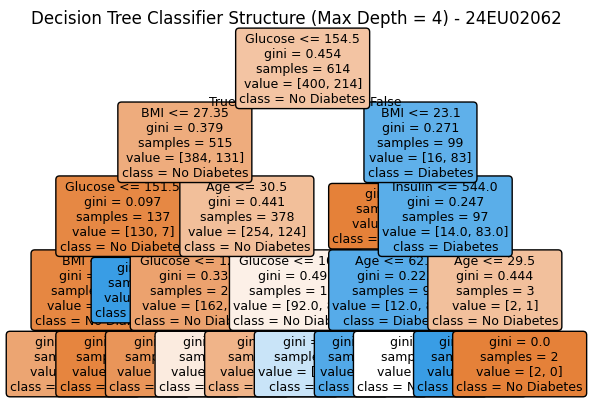

In [25]:
plot_tree(tree_clf, feature_names=pima_cols[:-1], class_names=['No Diabetes', 'Diabetes'], filled=True, rounded=True,  fontsize=9)
plt.title("Decision Tree Classifier Structure (Max Depth = 4) - 24EU02062")
plt.show()

### Subtask 1.3: Visualizing the Trained Decision Tree Structure
**Concept:** Plot and inspect the trained Decision Tree structure using plot_tree to identify node thresholds, Gini impurity levels, and split paths.


In [26]:
from sklearn.tree import DecisionTreeRegressor

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

In [29]:
boston_df = pd.read_csv(boston_url)

In [30]:
boston_features = [col for col in boston_df.columns if col != 'medv']

In [31]:
X_boston = boston_df[boston_features]

In [32]:
y_boston = boston_df['medv']

In [33]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_boston, y_boston, test_size=0.20, random_state=42)

In [34]:
scaler_r = StandardScaler()

In [35]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)

In [36]:
X_test_r_scaled = scaler_r.transform(X_test_r)

In [37]:
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)

In [38]:
tree_reg.fit(X_train_r_scaled, y_train_r)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [39]:
print("Decision Tree Regressor trained successfully. Max Depth set to 5.")

Decision Tree Regressor trained successfully. Max Depth set to 5.


### Subtask 1.5: Evaluating Decision Tree Regressor Predictions
**Concept:** Compute continuous evaluation metrics (MSE and R2 Score) for your Decision Tree Regressor and plot actual versus predicted values.


In [40]:
from sklearn.metrics import mean_squared_error, r2_score

In [41]:
import numpy as np

In [42]:
reg_preds = tree_reg.predict(X_test_r_scaled)

In [43]:
mse_val = mean_squared_error(y_test_r, reg_preds)

In [44]:
rmse_val = np.sqrt(mse_val)

In [45]:
r2_val = r2_score(y_test_r, reg_preds)

In [46]:
print(f"Mean Squared Error (MSE): {mse_val:.4f}")

Mean Squared Error (MSE): 8.5539


In [47]:
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f} ($1000s)")

Root Mean Squared Error (RMSE): 2.9247 ($1000s)


In [48]:
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")

R2 Coefficient of Determination: 0.8834



In [49]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

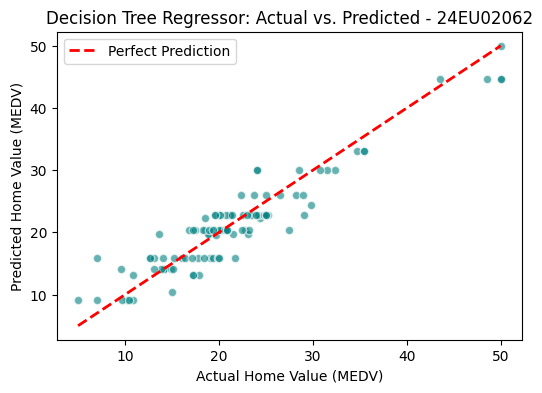

In [50]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test_r, reg_preds, color='teal', alpha=0.6, edgecolor='white')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("Decision Tree Regressor: Actual vs. Predicted - 24EU02062")
plt.xlabel("Actual Home Value (MEDV)")
plt.ylabel("Predicted Home Value (MEDV)")
plt.legend()
plt.show()

### Subtask 2.1: Standard Scaling and High-Dimensional Target Map
**Concept:** Import warnings suppression, load the high-dimensional Sonar dataset, map targets ('M'/'R') to binary values, standardize features, and perform a stratified split.


In [51]:
import warnings

In [52]:
import pandas as pd

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [56]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [57]:
sonar_columns = sonar_features + ['Class']

In [58]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [59]:
X_sonar = sonar_df[sonar_features]


In [60]:
y_sonar = sonar_df['Class_numeric']

In [61]:
scaler_sonar = StandardScaler()

In [62]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [63]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42)

In [64]:
print("Sonar Training Set Shape:", X_train_s.shape)


Sonar Training Set Shape: (145, 60)


In [65]:

print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Test Set Shape: (63, 60)


### Subtask 2.2: Implementing a Bagging Classifier
**Concept:** Train a Bagging Classifier using bootstrap aggregation on base Decision Tree estimators to reduce model variance.


In [66]:
from sklearn.ensemble import BaggingClassifier

In [67]:
from sklearn.metrics import accuracy_score

In [68]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

In [69]:
bagging_model.fit(X_train_s, y_train_s)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=50, n_jobs=-1, random_state=42)

In [70]:
bagging_preds = bagging_model.predict(X_test_s)

In [71]:
bagging_accuracy = accuracy_score(y_test_s, bagging_preds)

In [72]:
print(f"Bagging Classifier Test Accuracy: {bagging_accuracy * 100:.2f}%")

Bagging Classifier Test Accuracy: 80.95%


### Subtask 2.3: Implementing a Random Forest Classifier
**Concept:** Train a Random Forest Classifier to observe how feature subspace selection decorrelates individual trees and controls variance.


In [73]:
from sklearn.ensemble import RandomForestClassifier

In [74]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [75]:
rf_model.fit(X_train_s, y_train_s)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [76]:
rf_preds = rf_model.predict(X_test_s)

In [77]:
rf_accuracy = accuracy_score(y_test_s, rf_preds)

In [78]:
print(f"Random Forest Classifier Test Accuracy: {rf_accuracy * 100:.2f}%")


Random Forest Classifier Test Accuracy: 82.54%


### Subtask 2.4: Implementing a Voting Ensemble Classifier
**Concept:** Develop a Voting Classifier (Soft Voting) combining Logistic Regression, SVM, and a Decision Tree to establish consensus decisions.


In [79]:
from sklearn.ensemble import VotingClassifier

In [80]:
from sklearn.linear_model import LogisticRegression

In [81]:
from sklearn.svm import SVC

In [82]:
estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

In [83]:
voting_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

In [84]:
voting_model.fit(X_train_s, y_train_s)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=500,
                                                 random_state=42)),
                             ('dt',
                              DecisionTreeClassifier(max_depth=5,
                                                     random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 n_jobs=-1, voting='soft')

In [85]:
voting_preds = voting_model.predict(X_test_s)

In [86]:
voting_accuracy = accuracy_score(y_test_s, voting_preds)

In [87]:
print(f"Voting Classifier Test Accuracy: {voting_accuracy * 100:.2f}%")

Voting Classifier Test Accuracy: 87.30%


### Subtask 2.5: Performance Comparison of Ensemble Techniques
**Concept:** Tabulate and plot a bar chart comparing test accuracies across Bagging, Random Forest, and Voting ensemble models.


In [88]:
import matplotlib.pyplot as plt

In [89]:
import seaborn as sns

In [90]:
ensemble_results = pd.DataFrame({
    'Ensemble Technique': ['Bagging (DT Base)', 'Random Forest', 'Voting Classifier (Soft)'],
    'Test Accuracy (%)': [bagging_accuracy * 100, rf_accuracy * 100, voting_accuracy * 100]
})

In [91]:
print("--- Performance Comparison ---")
print(ensemble_results.to_string(index=False))

--- Performance Comparison ---
      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          80.952381
           Random Forest          82.539683
Voting Classifier (Soft)          87.301587


In [92]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

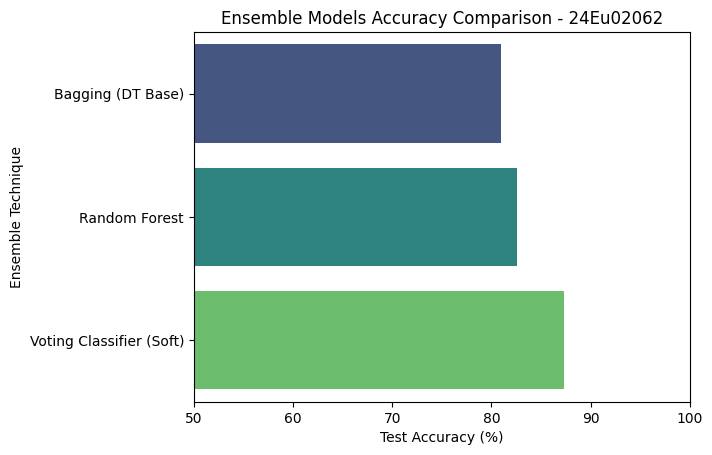

In [95]:
sns.barplot(data=ensemble_results, x='Test Accuracy (%)', y='Ensemble Technique', palette='viridis')
plt.xlim([50, 100])
plt.title("Ensemble Models Accuracy Comparison - 24Eu02062")
plt.show()


## Task 3: Implement and compare boosting techniques including AdaBoost and Gradient Boosting for predictive enhancement
*Continuous Evaluations on Sonar Dataset*


### Subtask 3.1: Implementing the AdaBoost Classifier
**Concept:** Import warnings suppression and train an AdaBoost Classifier to observe how sequential boosting assigns higher weights to misclassified instances.


In [96]:
import warnings

In [97]:
warnings.filterwarnings("ignore")

In [98]:
from sklearn.ensemble import AdaBoostClassifier

In [99]:
from sklearn.metrics import accuracy_score

In [100]:
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)

In [101]:
adaboost_model.fit(X_train_s, y_train_s)

AdaBoostClassifier(random_state=42)

In [102]:
ada_preds = adaboost_model.predict(X_test_s)

In [103]:
ada_accuracy = accuracy_score(y_test_s, ada_preds)

In [104]:
print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")

AdaBoost Classifier Test Accuracy: 85.71%


### Subtask 3.2: Implementing the Gradient Boosting Classifier
**Concept:** Train a baseline Gradient Boosting Classifier to observe sequential boosting optimization over loss function gradients.


In [105]:
from sklearn.ensemble import GradientBoostingClassifier

In [106]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [107]:
gb_model.fit(X_train_s, y_train_s)


GradientBoostingClassifier(random_state=42)

In [108]:
gb_preds = gb_model.predict(X_test_s)

In [109]:
gb_accuracy = accuracy_score(y_test_s, gb_preds)

In [110]:
print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")

Gradient Boosting Classifier Test Accuracy: 80.95%


### Subtask 3.3: Hyperparameter Tuning for Gradient Boosting Classifier
**Concept:** Use GridSearchCV to tune hyperparameters (learning rate, tree count, max depth) of your Gradient Boosting Classifier to optimize model fit.


In [111]:
from sklearn.model_selection import GridSearchCV

In [112]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}

In [113]:
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

In [114]:
grid_gb.fit(X_train_s, y_train_s)

GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [115]:
best_gb = grid_gb.best_estimator_

In [116]:
tuned_gb_preds = best_gb.predict(X_test_s)

In [117]:
tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)

In [118]:
print("Optimal Hyperparameters Selected:", grid_search_params := grid_gb.best_params_)

Optimal Hyperparameters Selected: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}


In [119]:
print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")

Tuned Gradient Boosting Test Accuracy: 74.60%


### Subtask 3.4: Master Comparison: Ensemble vs. Boosting Models
**Concept:** Create a comprehensive summary table comparing the test accuracies of all models trained in Tasks 2 and 3.


In [120]:
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier',
        'Random Forest Classifier',
        'Voting Ensemble (Soft)',
        'AdaBoost Classifier',
        'Base Gradient Boosting',
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100,
        rf_accuracy * 100,
        voting_accuracy * 100,
        ada_accuracy * 100,
        gb_accuracy * 100,
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)

In [121]:
print("--- Master Performance Table: Tasks 2 & 3 ---")

--- Master Performance Table: Tasks 2 & 3 ---


In [122]:
print(master_comparison.to_string(index=False))

        Model Classifier  Accuracy (%)
  Voting Ensemble (Soft)     87.301587
     AdaBoost Classifier     85.714286
Random Forest Classifier     82.539683
      Bagging Classifier     80.952381
  Base Gradient Boosting     80.952381
 Tuned Gradient Boosting     74.603175


### Subtask 3.5: Plotting Feature Importances (Random Forest vs. Tuned Gradient Boosting)
**Concept:** Plot and compare the feature importances derived from both the Random Forest and the tuned Gradient Boosting models.


In [123]:
import matplotlib.pyplot as plt

In [124]:
import numpy as np

In [125]:
rf_importances = rf_model.feature_importances_

In [126]:
gb_importances = best_gb.feature_importances_

In [127]:
top_indices_rf = np.argsort(rf_importances)[-10:]

In [128]:
top_indices_gb = np.argsort(gb_importances)[-10:]

In [129]:
features_list = [f"F_{i}" for i in range(1, 61)]

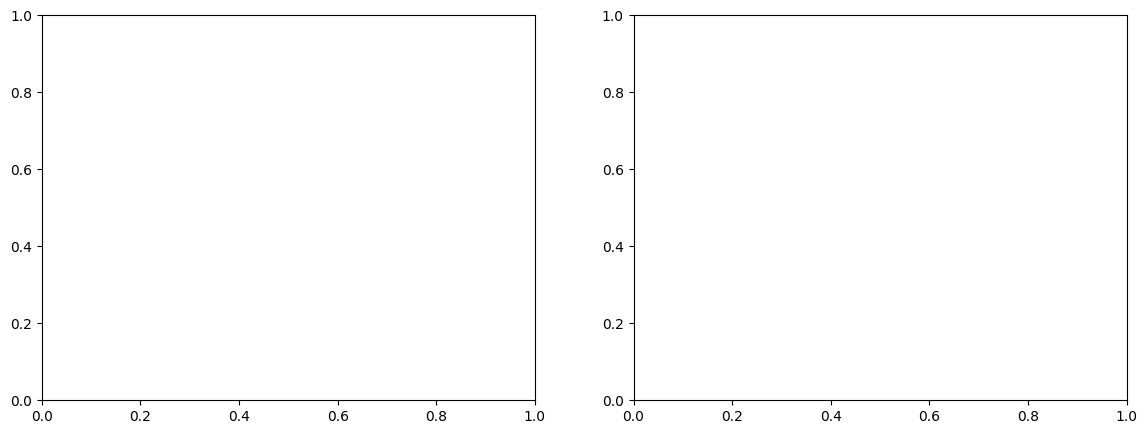

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [131]:
axes[0].barh(range(10), rf_importances[top_indices_rf], color='royalblue', align='center')

<BarContainer object of 10 artists>

In [132]:
axes[0].set_yticks(range(10))

In [133]:
axes[0].set_yticklabels([features_list[i] for i in top_indices_rf])

[Text(0, 0, 'F_1'),
 Text(0, 1, 'F_36'),
 Text(0, 2, 'F_49'),
 Text(0, 3, 'F_52'),
 Text(0, 4, 'F_12'),
 Text(0, 5, 'F_47'),
 Text(0, 6, 'F_48'),
 Text(0, 7, 'F_10'),
 Text(0, 8, 'F_11'),
 Text(0, 9, 'F_9')]

In [134]:
axes[0].set_title("Top 10 Feature Importances: Random Forest")

Text(0.5, 1.0, 'Top 10 Feature Importances: Random Forest')

In [135]:
axes[0].set_xlabel("Relative Importance")

Text(0.5, 4.444444444444445, 'Relative Importance')

In [136]:
axes[1].barh(range(10), gb_importances[top_indices_gb], color='darkorange', align='center')

<BarContainer object of 10 artists>

In [137]:
axes[1].set_yticks(range(10))

In [138]:
axes[1].set_yticklabels([features_list[i] for i in top_indices_gb])

[Text(0, 0, 'F_43'),
 Text(0, 1, 'F_21'),
 Text(0, 2, 'F_17'),
 Text(0, 3, 'F_45'),
 Text(0, 4, 'F_47'),
 Text(0, 5, 'F_37'),
 Text(0, 6, 'F_4'),
 Text(0, 7, 'F_28'),
 Text(0, 8, 'F_9'),
 Text(0, 9, 'F_11')]

In [139]:
axes[1].set_title("Top 10 Feature Importances: Tuned Gradient Boosting")

Text(0.5, 1.0, 'Top 10 Feature Importances: Tuned Gradient Boosting')

In [140]:
axes[1].set_xlabel("Relative Importance")

Text(0.5, 4.444444444444445, 'Relative Importance')

In [141]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [142]:
plt.show()